In [1]:
from sklearn.cluster import AgglomerativeClustering, DBSCAN, KMeans
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

## Hierarchinis klasterizavimas

In [2]:
distance_matrix = np.load('dist_mat.npy')
original_data = np.load('original_data.npy')
labels = np.load('ship-types.npy')

In [3]:
from sklearn.metrics import silhouette_score

In [ ]:
clusters_of_n = []
silhouette_scores = []
inertia_scores = []

for n in range(2, 30):
    clusters = AgglomerativeClustering(n_clusters=n, metric='precomputed', linkage='average')\
        .fit_predict(distance_matrix)

    score = silhouette_score(distance_matrix, clusters, metric='precomputed')
    silhouette_scores.append(score)
    clusters_of_n.append(clusters)

    # Elbow method: compute inertia (mean intra-cluster distance)
    inertia = 0
    for cluster_id in range(n):
        members = np.where(clusters == cluster_id)[0]
        if len(members) > 1:
            pairwise = distance_matrix[np.ix_(members, members)]
            inertia += pairwise.sum() / 2

    inertia_scores.append(inertia)

## Pagal Jaccard indeksą galime palyginti tik su tikraisiais label'iais, tai mes negalim pagal jį parinkti optimalaus klasterių skaičiaus, tik įvertinti ir palyginti tarpusavyje

In [33]:
from sklearn.preprocessing import LabelEncoder

In [36]:
clusters = AgglomerativeClustering(5, metric='precomputed', linkage='average').fit_predict(distance_matrix)

labels = LabelEncoder().fit_transform(labels)

jaccard_score(clusters, labels, average='weighted')

0.1428417536362273

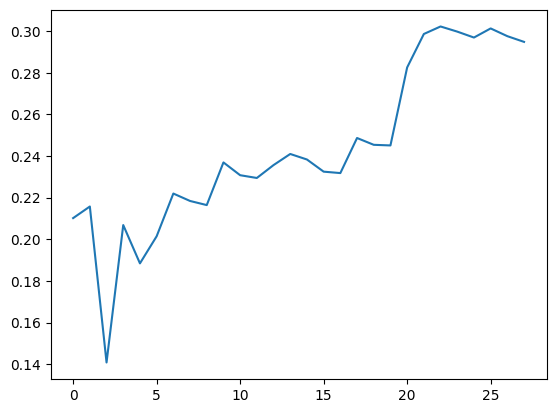

In [5]:
plt.plot( silhouette_scores )

In [6]:
np.argmax(silhouette_scores)

np.int64(22)

In [9]:
from sklearn.manifold import TSNE

In [10]:
tsne = TSNE(
    perplexity=500,
    early_exaggeration=24,
    learning_rate=10,
    n_components=2
)
embedding = tsne.fit_transform(distance_matrix)

In [11]:
clusters_of_n = []
silhouette_scores = []
inertia_scores = []

clusters = AgglomerativeClustering(n_clusters=n, metric='euclidean', linkage='average')\
    .fit_predict(embedding)

jaccard_score(clusters, labels, average='weighted')

In [37]:
clusters = AgglomerativeClustering(5, metric='euclidean', linkage='average').fit_predict(embedding)

labels = LabelEncoder().fit_transform(labels)

jaccard_score(clusters, labels, average='weighted')

0.17722863697697389

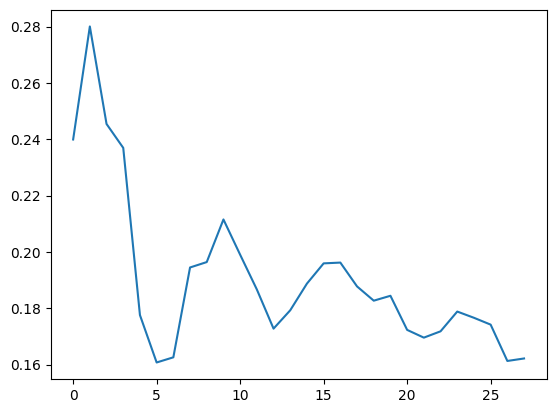

In [13]:
plt.plot(silhouette_scores)

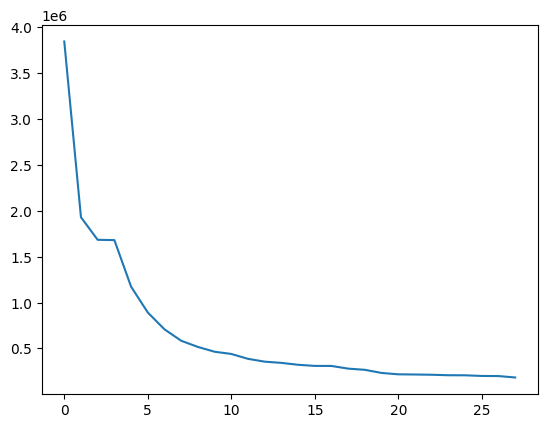

In [14]:
plt.plot(inertia_scores)

In [18]:
tsne25 = TSNE(
    perplexity=500,
    early_exaggeration=24,
    learning_rate=10,
    n_components=25,
    method='exact'
)
embedding25 = tsne25.fit_transform(distance_matrix)

In [19]:
clusters_of_n = []
silhouette_scores = []
inertia_scores = []

for n in range(2, 30):
    clusters = AgglomerativeClustering(n_clusters=n, metric='euclidean', linkage='average')\
        .fit_predict(embedding25)

    score = silhouette_score(distance_matrix, clusters, metric='precomputed')
    silhouette_scores.append(score)
    clusters_of_n.append(clusters)

    # Elbow method: compute inertia (mean intra-cluster distance)
    inertia = 0
    for cluster_id in range(n):
        members = np.where(clusters == cluster_id)[0]
        if len(members) > 1:
            pairwise = distance_matrix[np.ix_(members, members)]
            inertia += pairwise.sum() / 2

    inertia_scores.append(inertia)


In [38]:
clusters = AgglomerativeClustering(5, metric='euclidean', linkage='average').fit_predict(embedding25)

labels = LabelEncoder().fit_transform(labels)

jaccard_score(clusters, labels, average='weighted')

0.17046856141864553

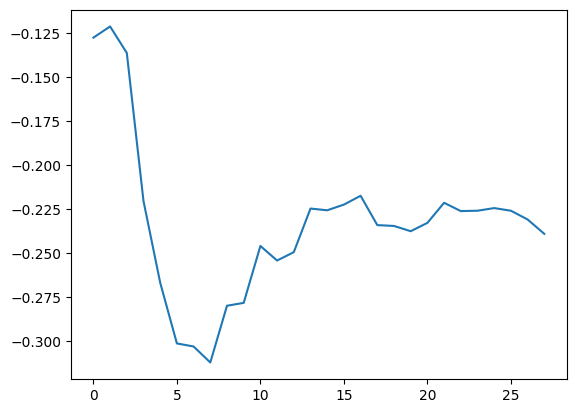

In [20]:
plt.plot(silhouette_scores)

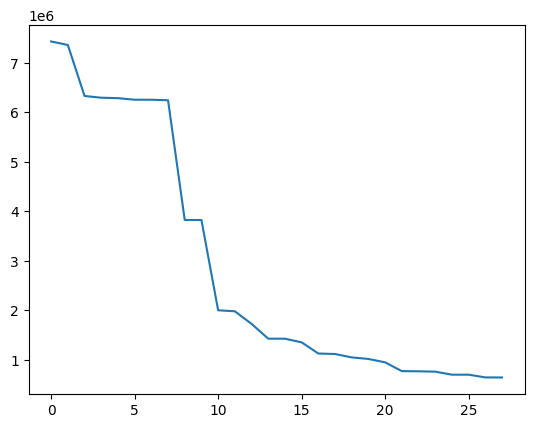

In [21]:
plt.plot(inertia_scores)

In [23]:
tsne100 = TSNE(
    perplexity=500,
    early_exaggeration=24,
    learning_rate=10,
    n_components=100,
    method='exact'
)
embedding100 = tsne100.fit_transform(distance_matrix)

In [24]:
clusters_of_n = []
silhouette_scores = []
inertia_scores = []

for n in range(2, 30):
    clusters = AgglomerativeClustering(n_clusters=n, metric='euclidean', linkage='average')\
        .fit_predict(embedding100)

    score = silhouette_score(distance_matrix, clusters, metric='precomputed')
    silhouette_scores.append(score)
    clusters_of_n.append(clusters)

    # Elbow method: compute inertia (mean intra-cluster distance)
    inertia = 0
    for cluster_id in range(n):
        members = np.where(clusters == cluster_id)[0]
        if len(members) > 1:
            pairwise = distance_matrix[np.ix_(members, members)]
            inertia += pairwise.sum() / 2

    inertia_scores.append(inertia)


In [39]:
clusters = AgglomerativeClustering(5, metric='euclidean', linkage='average').fit_predict(embedding100)

labels = LabelEncoder().fit_transform(labels)

jaccard_score(clusters, labels, average='weighted')

0.20000888888888887

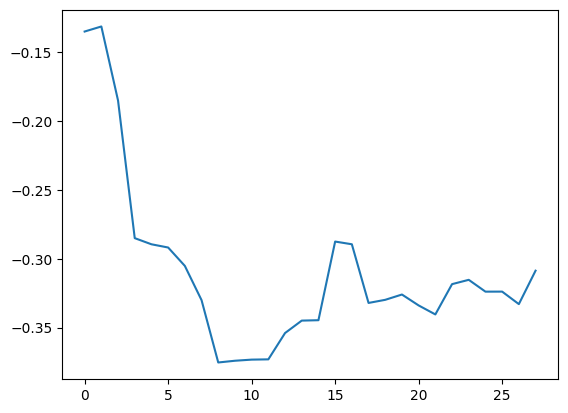

In [25]:
plt.plot(silhouette_scores)

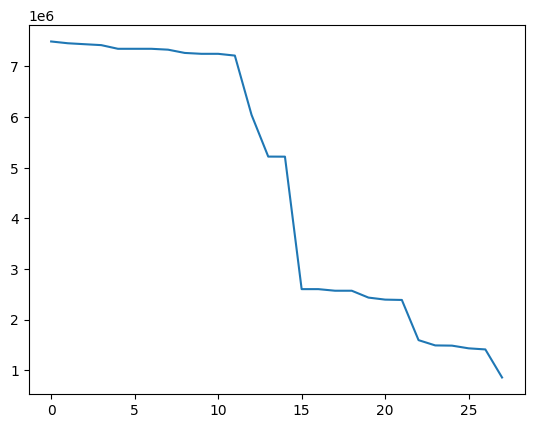

In [26]:
plt.plot(inertia_scores)